UJI NORMALITAS (KOLMOGOROV-SMIRNOV)

In [1]:
import pandas as pd
from scipy import stats

# ==========================================
# INPUT DATA
# ==========================================

df_tahunan = pd.read_csv('data_keuangan.csv')

# ==========================================
# DAFTAR VARIABEL RASIO
# ==========================================
rasio_list = ['ROIC', 'ROA', 'ROE', 'NPM', 'DER', 'TDTC', 'CR', 'FAT']


# ==========================================
# PROSES UJI KOLMOGOROV-SMIRNOV
# ==========================================
hasil_ks = []

for rasio in rasio_list:
    if rasio not in df_tahunan.columns:
        print(f"Peringatan: Kolom '{rasio}' tidak ditemukan di CSV Anda!")
        continue

    data = df_tahunan[rasio].dropna()

    data = data.astype(str).str.replace(',', '.').astype(float)

    if len(data) < 3:
        continue

    # Menghitung parameter sampel (mean dan standar deviasi)
    mean_val = data.mean()
    std_val = data.std()

    # Melakukan Uji KS
    stat, p_value = stats.kstest(data, 'norm', args=(mean_val, std_val))

    keputusan = 'Tolak H₀' if p_value < 0.05 else 'Gagal Tolak H₀'

    hasil_ks.append({
        'Rasio'      : rasio,
        'Statistik D': round(stat, 4),
        'p-value'    : round(p_value, 4),
        'Keputusan'  : keputusan
    })


# ==========================================
# MENAMPILKAN HASIL UJI
# ==========================================
df_ks = pd.DataFrame(hasil_ks)
print("=== HASIL UJI NORMALITAS KOLMOGOROV-SMIRNOV ===")
print(df_ks)

=== HASIL UJI NORMALITAS KOLMOGOROV-SMIRNOV ===
  Rasio  Statistik D  p-value       Keputusan
0  ROIC       0.2792   0.6453  Gagal Tolak H₀
1   ROA       0.2680   0.6941  Gagal Tolak H₀
2   ROE       0.2590   0.7324  Gagal Tolak H₀
3   NPM       0.2916   0.5911  Gagal Tolak H₀
4   DER       0.2355   0.8257  Gagal Tolak H₀
5  TDTC       0.2155   0.8921  Gagal Tolak H₀
6    CR       0.1980   0.9367  Gagal Tolak H₀
7   FAT       0.2467   0.7827  Gagal Tolak H₀


UJI HOMOGENITAS VARIANSI (ANOMV)

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import f as f_dist

# ============================================================
# LOAD DATA
# ============================================================
df_kuartalan = pd.read_csv('data_keuangan Q.csv')

rasio_list = ['ROIC', 'ROA', 'ROE', 'NPM', 'DER', 'TDTC', 'CR', 'FAT']
tahun_list = [2020, 2021, 2022, 2023, 2024, 2025]

# Fix format koma ke titik
for rasio in rasio_list:
    if rasio in df_kuartalan.columns:
        df_kuartalan[rasio] = df_kuartalan[rasio].astype(str).str.replace(',', '.').astype(float)

# ============================================================
# PARAMETER ANOMV
# ============================================================
I             = 6
n             = 4
N             = I * n        # = 24
vi            = n - 1        # = 3  (df kelompok)
ve            = N - I        # = 18 (df galat)
alpha         = 0.05
alpha_koreksi = alpha / (2 * I)  # = 0.05/12 = 0.00417

UDLv = f_dist.ppf(1 - alpha_koreksi, dfn=vi, dfd=ve)
LDLv = 1 / f_dist.ppf(1 - alpha_koreksi, dfn=ve, dfd=vi)

# ============================================================
# FUNGSI ANOMV
# ============================================================
def anomv(df_kuartalan, rasio, I=6, n=4):
    kelompok = [df_kuartalan[rasio].iloc[i*n:(i+1)*n].values for i in range(I)]
    Si2  = [np.var(k, ddof=1) for k in kelompok]
    SSe  = sum((n - 1) * s for s in Si2)
    MSe  = SSe / (N - I)
    Fi   = [s / MSe for s in Si2]
    return Si2, MSe, Fi

# ============================================================
# OUTPUT: SATU TABEL PER RASIO
# ============================================================
print("=" * 75)
print("            HASIL UJI HOMOGENITAS VARIANSI (ANOMV)")
print(f"  α = {alpha}  |  α/(2I) = {alpha_koreksi:.5f}  |  "
      f"UDLᵥ = {UDLv:.4f}  |  LDLᵥ = {LDLv:.4f}")
print(f"  vᵢ = {vi}  |  vₑ = {ve}")
print("=" * 75)

mse_per_rasio = {}

for rasio in rasio_list:
    Si2, MSe, Fi = anomv(df_kuartalan, rasio)
    mse_per_rasio[rasio] = MSe

    print(f"\n┌─ RASIO: {rasio}   MSe = {MSe:.6f}")
    print(f"  {'Tahun':<8} {'Sᵢ²':>14} {'Fᵢ = Sᵢ²/MSe':>16} {'Keputusan':>15}")
    print(f"  {'─'*55}")
    semua_homogen = True
    for tahun, s, f in zip(tahun_list, Si2, Fi):
        status = "Homogen" if LDLv <= f <= UDLv else "TIDAK Homogen"
        if status != "Homogen":
            semua_homogen = False
        print(f"  {tahun:<8} {s:>14.6f} {f:>16.6f} {status:>15}")
    print(f"  {'─'*55}")
    kesimpulan = "✔ Semua kelompok HOMOGEN" if semua_homogen else "✘ Ada kelompok TIDAK HOMOGEN"
    print(f"  Kesimpulan: {kesimpulan}")

# ============================================================
# RINGKASAN MSe (input untuk ANOM)
# ============================================================
print(f"\n{'=' * 75}")
print("  RINGKASAN MSe PER RASIO ")
print(f"{'=' * 75}")
print(f"  {'Rasio':<8} {'MSe':>14}")
print(f"  {'─'*24}")
for rasio, mse in mse_per_rasio.items():
    print(f"  {rasio:<8} {mse:>14.6f}")

            HASIL UJI HOMOGENITAS VARIANSI (ANOMV)
  α = 0.05  |  α/(2I) = 0.00417  |  UDLᵥ = 6.2856  |  LDLᵥ = 0.0206
  vᵢ = 3  |  vₑ = 18

┌─ RASIO: ROIC   MSe = 0.710446
  Tahun               Sᵢ²     Fᵢ = Sᵢ²/MSe       Keputusan
  ───────────────────────────────────────────────────────
  2020           3.314692         4.665650         Homogen
  2021           0.045758         0.064408         Homogen
  2022           0.417867         0.588175         Homogen
  2023           0.021067         0.029653         Homogen
  2024           0.071492         0.100629         Homogen
  2025           0.391800         0.551485         Homogen
  ───────────────────────────────────────────────────────
  Kesimpulan: ✔ Semua kelompok HOMOGEN

┌─ RASIO: ROA   MSe = 0.774526
  Tahun               Sᵢ²     Fᵢ = Sᵢ²/MSe       Keputusan
  ───────────────────────────────────────────────────────
  2020           3.708567         4.788173         Homogen
  2021           0.008558         0.011050   TIDAK 

           HASIL ANALISIS ANOM KINERJA KEUANGAN
  h = 2.85  |  α = 0.05  |  I = 6  |  n = 4  |  N = 24  |  ν = 18
  Rumus UDL/LDL: ȳ.. ± h · √(MSe · (I-1)/N)  [Persamaan 2.41-2.42]

┌─ RASIO: ROIC
  Grand Mean (ȳ..) = 0.9371  |  UDL = 2.0335  |  LDL = -0.1594
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         0.1625          -0.7746 Tidak Signifikan
  2021         1.1775           0.2404 Tidak Signifikan
  2022         0.9000          -0.0371 Tidak Signifikan
  2023         1.2100           0.2729 Tidak Signifikan
  2024         1.2925           0.3554 Tidak Signifikan
  2025         0.8800          -0.0571 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


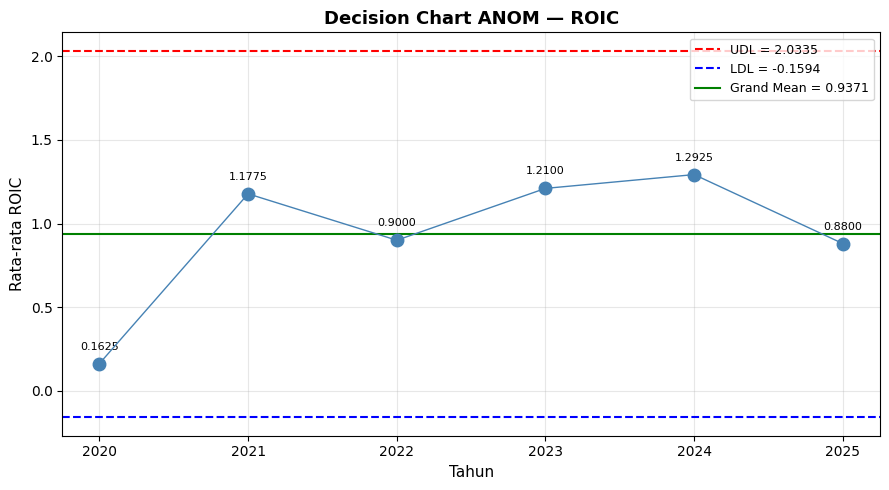

  → Decision chart disimpan: decision_chart_ROIC.png

┌─ RASIO: ROA
  Grand Mean (ȳ..) = 0.2754  |  UDL = 1.4202  |  LDL = -0.8694
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         0.1050          -0.1704 Tidak Signifikan
  2021         0.4725           0.1971 Tidak Signifikan
  2022         0.3425           0.0671 Tidak Signifikan
  2023         0.3325           0.0571 Tidak Signifikan
  2024         0.4675           0.1921 Tidak Signifikan
  2025        -0.0675          -0.3429 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


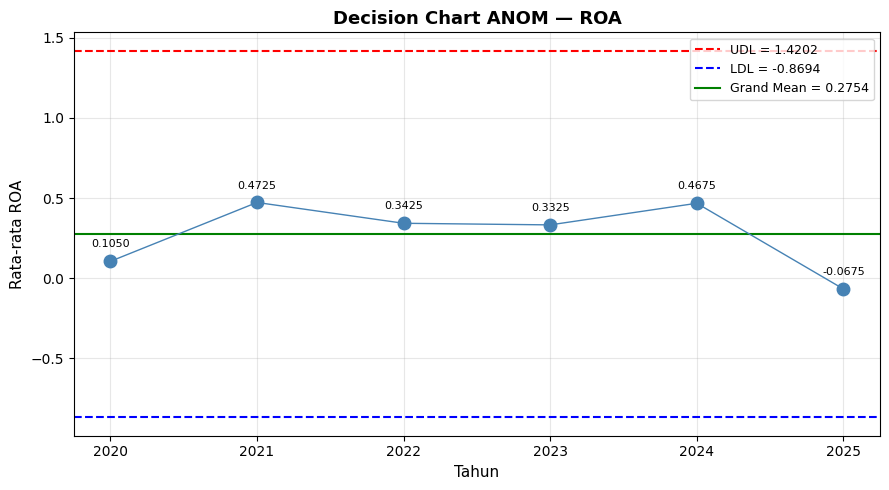

  → Decision chart disimpan: decision_chart_ROA.png

┌─ RASIO: ROE
  Grand Mean (ȳ..) = 0.9067  |  UDL = 4.9611  |  LDL = -3.1478
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         0.2900          -0.6167 Tidak Signifikan
  2021         1.6425           0.7358 Tidak Signifikan
  2022         1.2300           0.3233 Tidak Signifikan
  2023         1.0950           0.1883 Tidak Signifikan
  2024         1.5625           0.6558 Tidak Signifikan
  2025        -0.3800          -1.2867 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


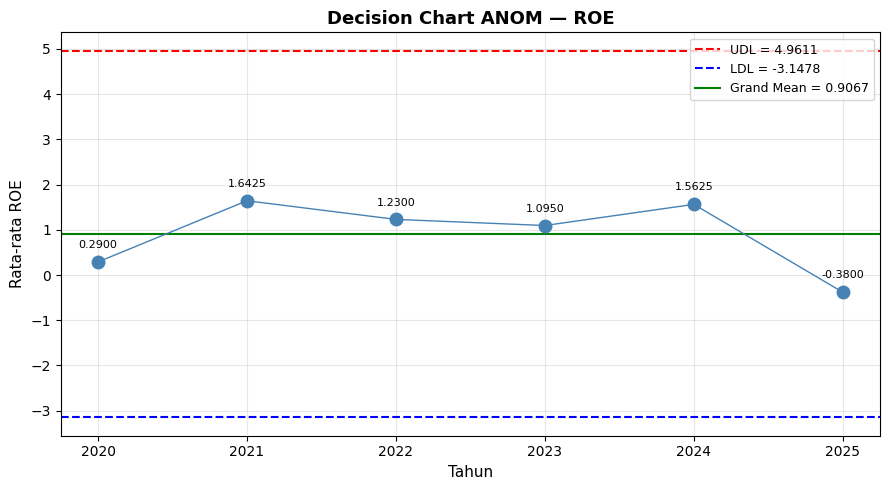

  → Decision chart disimpan: decision_chart_ROE.png

┌─ RASIO: NPM
  Grand Mean (ȳ..) = 2.9979  |  UDL = 15.4189  |  LDL = -9.4231
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         1.2650          -1.7329 Tidak Signifikan
  2021         4.8300           1.8321 Tidak Signifikan
  2022         3.7875           0.7896 Tidak Signifikan
  2023         3.6750           0.6771 Tidak Signifikan
  2024         4.8825           1.8846 Tidak Signifikan
  2025        -0.4525          -3.4504 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


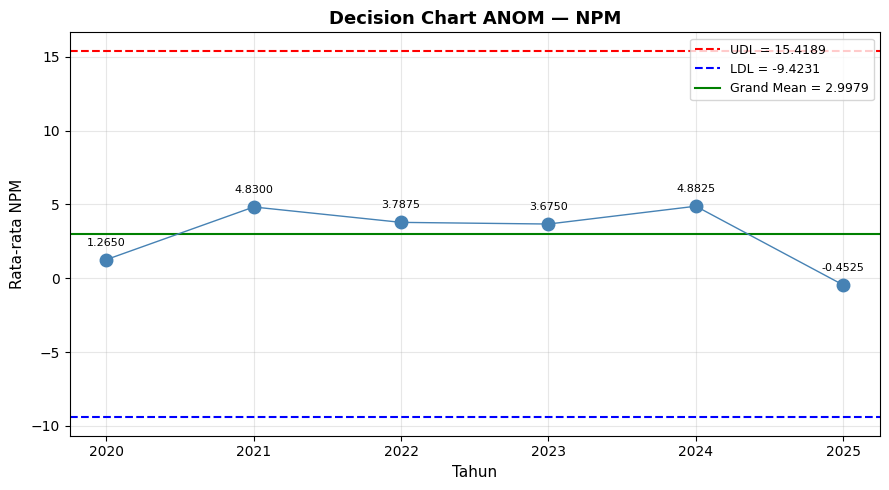

  → Decision chart disimpan: decision_chart_NPM.png

┌─ RASIO: DER
  Grand Mean (ȳ..) = 175.9983  |  UDL = 190.8493  |  LDL = 161.1474
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020       162.2675         -13.7308 Tidak Signifikan
  2021       173.3425          -2.6558 Tidak Signifikan
  2022       189.3000          13.3017 Tidak Signifikan
  2023       165.7450         -10.2533 Tidak Signifikan
  2024       173.9200          -2.0783 Tidak Signifikan
  2025       191.4150          15.4167    ★ DI ATAS UDL
  ────────────────────────────────────────────────────
  Kesimpulan: Ada kelompok yang menyimpang signifikan


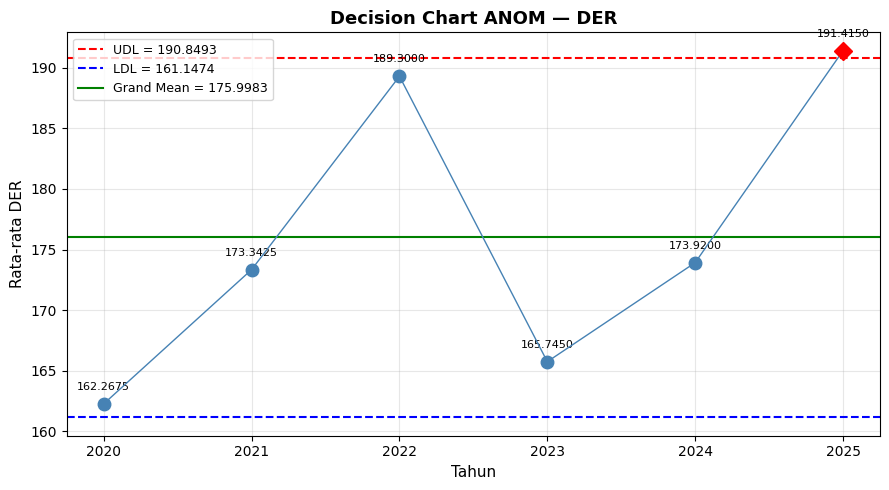

  → Decision chart disimpan: decision_chart_DER.png

┌─ RASIO: TDTC
  Grand Mean (ȳ..) = 63.6700  |  UDL = 65.5127  |  LDL = 61.8273
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020        61.8325          -1.8375 Tidak Signifikan
  2021        63.4050          -0.2650 Tidak Signifikan
  2022        65.3175           1.6475 Tidak Signifikan
  2023        62.3525          -1.3175 Tidak Signifikan
  2024        63.4825          -0.1875 Tidak Signifikan
  2025        65.6300           1.9600    ★ DI ATAS UDL
  ────────────────────────────────────────────────────
  Kesimpulan: Ada kelompok yang menyimpang signifikan


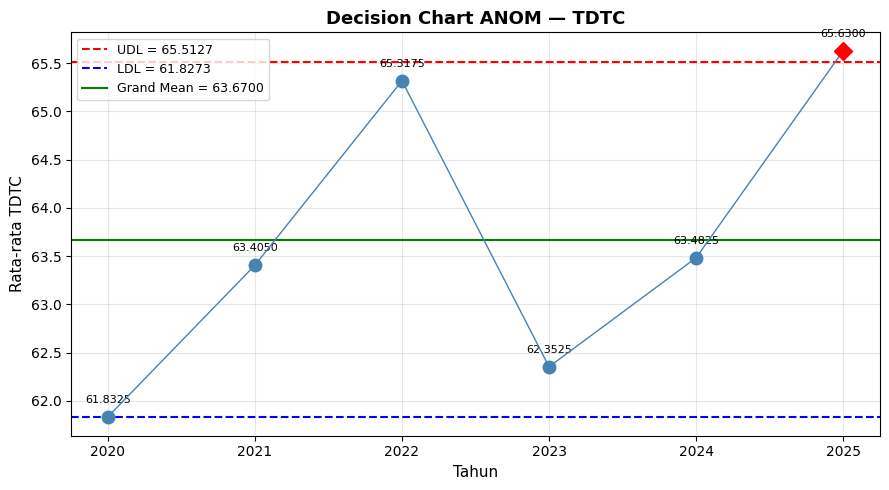

  → Decision chart disimpan: decision_chart_TDTC.png

┌─ RASIO: CR
  Grand Mean (ȳ..) = 0.3370  |  UDL = 0.4065  |  LDL = 0.2675
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         0.3585           0.0215 Tidak Signifikan
  2021         0.3347          -0.0022 Tidak Signifikan
  2022         0.3257          -0.0112 Tidak Signifikan
  2023         0.2833          -0.0537 Tidak Signifikan
  2024         0.3245          -0.0125 Tidak Signifikan
  2025         0.3950           0.0580 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


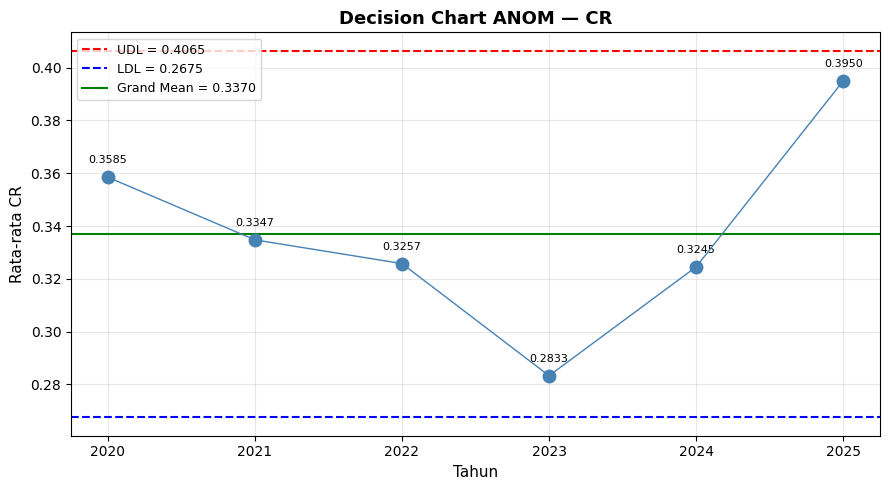

  → Decision chart disimpan: decision_chart_CR.png

┌─ RASIO: FAT
  Grand Mean (ȳ..) = 0.1320  |  UDL = 0.1410  |  LDL = 0.1229
  Tahun            ȳᵢ    Dᵢ = ȳᵢ - ȳ..        Keputusan
  ────────────────────────────────────────────────────
  2020         0.1328           0.0008 Tidak Signifikan
  2021         0.1360           0.0040 Tidak Signifikan
  2022         0.1265          -0.0055 Tidak Signifikan
  2023         0.1242          -0.0077 Tidak Signifikan
  2024         0.1335           0.0015 Tidak Signifikan
  2025         0.1388           0.0068 Tidak Signifikan
  ────────────────────────────────────────────────────
  Kesimpulan: Tidak ada kelompok yang menyimpang signifikan


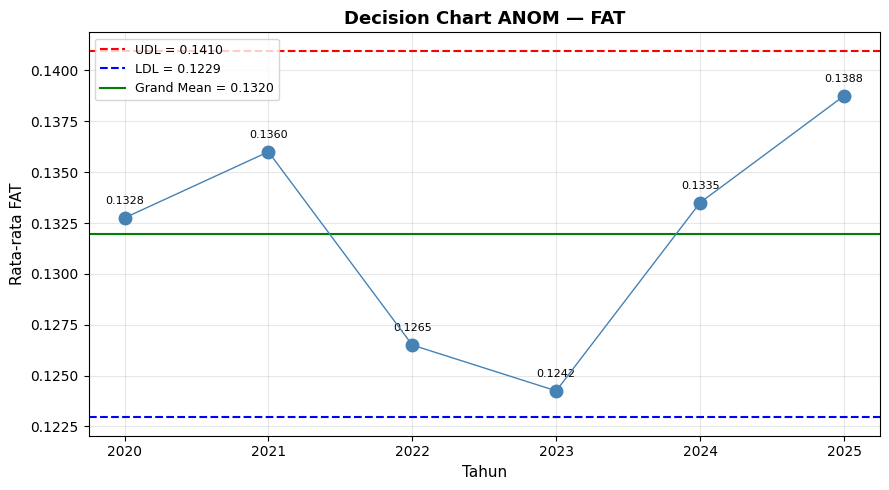

  → Decision chart disimpan: decision_chart_FAT.png

  RINGKASAN HASIL ANOM — SEMUA RASIO
  Rasio      Grand Mean        UDL        LDL                          Kesimpulan
  ────────────────────────────────────────────────────────────────────────
  ROIC           0.9371     2.0335    -0.1594       Tidak ada kelompok signifikan
  ROA            0.2754     1.4202    -0.8694       Tidak ada kelompok signifikan
  ROE            0.9067     4.9611    -3.1478       Tidak ada kelompok signifikan
  NPM            2.9979    15.4189    -9.4231       Tidak ada kelompok signifikan
  DER          175.9983   190.8493   161.1474      Terdapat kelompok signifikan ★
  TDTC          63.6700    65.5127    61.8273      Terdapat kelompok signifikan ★
  CR             0.3370     0.4065     0.2675       Tidak ada kelompok signifikan
  FAT            0.1320     0.1410     0.1229       Tidak ada kelompok signifikan


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================
df_kuartalan = pd.read_csv('data_keuangan Q.csv')

rasio_list = ['ROIC', 'ROA', 'ROE', 'NPM', 'DER', 'TDTC', 'CR', 'FAT']
tahun_list = [2020, 2021, 2022, 2023, 2024, 2025]

for rasio in rasio_list:
    if rasio in df_kuartalan.columns:
        df_kuartalan[rasio] = df_kuartalan[rasio].astype(str).str.replace(',', '.').astype(float)

# ============================================================
# PARAMETER ANOM
# ============================================================
I   = 6
n   = 4
N   = I * n
h   = 2.85     # h(0.05; 6; 18) dari tabel SMM Nelson & Wludyka (2021)

# MSe dari hasil ANOMV
mse_per_rasio = {
    'ROIC': 0.710446,
    'ROA' : 0.774526,
    'ROE' : 9.714481,
    'NPM' : 91.172235,
    'DER' : 130.335231,
    'TDTC': 2.006678,
    'CR'  : 0.002855,
    'FAT' : 0.000048,
}

# ============================================================
# FUNGSI ANOM
# ============================================================
def hitung_anom(df_kuartalan, rasio, MSe, I=6, n=4, N=24, h=2.85):

    # Grand Mean dari semua N observasi
    grand_mean = df_kuartalan[rasio].sum() / N

    # Rata-rata per kelompok tahun (ȳᵢ)
    yi_bar = np.array([
        df_kuartalan[rasio].iloc[i*n:(i+1)*n].mean() for i in range(I)
    ])

    # Statistik uji Di
    Di = yi_bar - grand_mean

    # Decision Limits (kasus balanced)
    margin = h * np.sqrt(MSe * (I - 1) / N)
    UDL = grand_mean + margin
    LDL = grand_mean - margin

    return yi_bar, grand_mean, Di, UDL, LDL

# ============================================================
# OUTPUT TABEL + DECISION CHART PER RASIO
# ============================================================
print("=" * 70)
print("           HASIL ANALISIS ANOM KINERJA KEUANGAN")
print(f"  h = {h}  |  α = 0.05  |  I = {I}  |  n = {n}  |  N = {N}  |  ν = {N-I}")
print(f"  Rumus UDL/LDL: ȳ.. ± h · √(MSe · (I-1)/N)  [Persamaan 2.41-2.42]")
print("=" * 70)

for rasio in rasio_list:
    MSe = mse_per_rasio[rasio]
    yi_bar, GM, Di, UDL, LDL = hitung_anom(df_kuartalan, rasio, MSe)

    # ── TABEL ─────────────────────────────────────────────
    print(f"\n┌─ RASIO: {rasio}")
    print(f"  Grand Mean (ȳ..) = {GM:.4f}  |  "
          f"UDL = {UDL:.4f}  |  LDL = {LDL:.4f}")
    print(f"  {'Tahun':<8} {'ȳᵢ':>10} {'Dᵢ = ȳᵢ - ȳ..':>16} {'Keputusan':>16}")
    print(f"  {'─'*52}")

    ada_anomali = False
    for i, tahun in enumerate(tahun_list):
        if yi_bar[i] > UDL:
            status = "★ DI ATAS UDL"
            ada_anomali = True
        elif yi_bar[i] < LDL:
            status = "★ DI BAWAH LDL"
            ada_anomali = True
        else:
            status = "Tidak Signifikan"
        print(f"  {tahun:<8} {yi_bar[i]:>10.4f} {Di[i]:>16.4f} {status:>16}")

    print(f"  {'─'*52}")
    kesimpulan = "Ada kelompok yang menyimpang signifikan" if ada_anomali \
                 else "Tidak ada kelompok yang menyimpang signifikan"
    print(f"  Kesimpulan: {kesimpulan}")

    # ── DECISION CHART ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axhline(UDL, color='red',   linestyle='--', linewidth=1.5,
               label=f'UDL = {UDL:.4f}')
    ax.axhline(LDL, color='blue',  linestyle='--', linewidth=1.5,
               label=f'LDL = {LDL:.4f}')
    ax.axhline(GM,  color='green', linestyle='-',  linewidth=1.5,
               label=f'Grand Mean = {GM:.4f}')

    for i, tahun in enumerate(tahun_list):
        if yi_bar[i] > UDL or yi_bar[i] < LDL:
            color  = 'red'
            marker = 'D'
        else:
            color  = 'steelblue'
            marker = 'o'
        ax.plot(tahun, yi_bar[i], marker=marker, color=color,
                markersize=9, zorder=5)
        ax.annotate(f'{yi_bar[i]:.4f}',
                    xy=(tahun, yi_bar[i]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8)

    ax.plot(tahun_list, yi_bar, color='steelblue',
            linewidth=1, linestyle='-', zorder=3)

    ax.set_title(f'Decision Chart ANOM — {rasio}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel(f'Rata-rata {rasio}', fontsize=11)
    ax.set_xticks(tahun_list)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'decision_chart_{rasio}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  → Decision chart disimpan: decision_chart_{rasio}.png")

# ============================================================
# RINGKASAN
# ============================================================
print(f"\n{'=' * 70}")
print("  RINGKASAN HASIL ANOM — SEMUA RASIO")
print(f"{'=' * 70}")
print(f"  {'Rasio':<8} {'Grand Mean':>12} {'UDL':>10} {'LDL':>10} {'Kesimpulan':>35}")
print(f"  {'─'*72}")

for rasio in rasio_list:
    MSe = mse_per_rasio[rasio]
    yi_bar, GM, Di, UDL, LDL = hitung_anom(df_kuartalan, rasio, MSe)
    anomali = any(y > UDL or y < LDL for y in yi_bar)
    ket = "Terdapat kelompok signifikan ★" if anomali else "Tidak ada kelompok signifikan"
    print(f"  {rasio:<8} {GM:>12.4f} {UDL:>10.4f} {LDL:>10.4f} {ket:>35}")